Intelligent Network Incident Resolution System

In [1]:
!pip install -q langgraph langchain langchain-google-genai google-search-results

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 890.7 kB/s eta 0:00:00


In [24]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END,START
from langchain_google_genai import ChatGoogleGenerativeAI
from serpapi import GoogleSearch

In [5]:
os.environ['GOOGLE_API_KEY']=''
os.environ['SERP_API_KEY']=''

In [6]:
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [74]:
# =========================================
# STATE SCHEMA
# =========================================

from typing import TypedDict


class FinanceState(TypedDict):

    # Applicant Input
    applicant_input: str

    # Applicant Analysis Stage
    applicant_profile: str
    income_stability: str
    missing_documents: bool
    spending_behavior: str
    financial_behavior: str

    # Verification Layer
    credit_score: int
    fraud_probability: str
    kyc_status: str
    employment_status: str
    debt_ratio: float

    # Routing
    assigned_department: str
    approval_decision: str

    # Decision Orchestration Outputs
    risk_summary: str
    approval_rationale: str
    loan_recommendation: str
    interest_suggestion: str
    applicant_notification: str

In [75]:
# =========================================
# APPLICANT ANALYSIS STAGE NODES
# =========================================

# 1. Applicant Profile Extraction

def applicant_profile_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    prompt = f"""
    Analyze this loan applicant profile.

    Applicant Information:
    {applicant_input}

    Summarize the applicant profile briefly.
    """

    response = llm.invoke(prompt)

    return {
        "applicant_profile": response.content
    }

In [76]:
# 2. Income Stability Analysis

def income_analysis_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "permanent" in applicant_input.lower():
        stability = "stable"

    elif "contract" in applicant_input.lower():
        stability = "medium"

    else:
        stability = "unstable"

    return {
        "income_stability": stability
    }

In [77]:
# 3. Missing Document Detection

def document_check_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "missing" in applicant_input.lower():
        missing = True

    else:
        missing = False

    return {
        "missing_documents": missing
    }

In [78]:
# 4. Spending Behavior Analysis

def spending_analysis_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "high credit card debt" in applicant_input.lower():
        behavior = "risky"

    else:
        behavior = "moderate"

    return {
        "spending_behavior": behavior,
        "financial_behavior": behavior
    }

In [79]:
# 4. Spending Behavior Analysis

def spending_analysis_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "high credit card debt" in applicant_input.lower():
        behavior = "risky"

    else:
        behavior = "moderate"

    return {
        "spending_behavior": behavior,
        "financial_behavior": behavior
    }

In [80]:
# =========================================
# APPLICANT MERGE NODE
# =========================================

def applicant_merge_node(state: FinanceState):

    print("Applicant Analysis Completed")

    return {}

In [81]:
# =========================================
# VERIFICATION LAYER NODES
# =========================================

# 1. Credit Validation

def credit_validation_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "excellent credit" in applicant_input.lower():
        score = 790

    elif "good credit" in applicant_input.lower():
        score = 720

    elif "poor credit" in applicant_input.lower():
        score = 520

    else:
        score = 650

    return {
        "credit_score": score
    }

In [82]:
# 2. Fraud Detection

def fraud_detection_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "fake" in applicant_input.lower():

        fraud = "high"

    else:

        fraud = "low"

    return {
        "fraud_probability": fraud
    }

In [83]:
# 3. KYC Verification

def kyc_verification_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "invalid id" in applicant_input.lower():

        status = "failed"

    else:

        status = "verified"

    return {
        "kyc_status": status
    }

In [84]:
# 4. Employment Verification

def employment_verification_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "unemployed" in applicant_input.lower():

        status = "unverified"

    else:

        status = "verified"

    return {
        "employment_status": status
    }

In [85]:
# 5. Debt Ratio Calculation

def debt_ratio_node(state: FinanceState):

    applicant_input = state["applicant_input"]

    if "high debt" in applicant_input.lower():

        ratio = 65.0

    else:

        ratio = 28.0

    return {
        "debt_ratio": ratio
    }

In [86]:
# =========================================
# VERIFICATION MERGE NODE
# =========================================

def verification_merge_node(state: FinanceState):

    print("Verification Layer Completed")

    return {}

In [87]:
# =========================================
# AGENT NODES
# =========================================

# 1. Fraud Investigation Agent

def fraud_agent_node(state: FinanceState):

    print("Fraud Investigation Agent Activated")

    return {
        "assigned_department": "Fraud Investigation Team",
        "approval_decision": "Under Investigation"
    }

In [88]:
# 2. Fast-track Approval Agent

def fasttrack_agent_node(state: FinanceState):

    print("Fast-track Approval Agent Activated")

    return {
        "assigned_department": "Fast-track Approval Team",
        "approval_decision": "Pre-Approved"
    }

In [89]:
# 3. Clarification Agent

def clarification_agent_node(state: FinanceState):

    print("Clarification Agent Activated")

    return {
        "assigned_department": "Document Clarification Team",
        "approval_decision": "Pending Documents"
    }

In [90]:
# 4. Manual Review Agent

def manual_review_agent_node(state: FinanceState):

    print("Manual Review Agent Activated")

    return {
        "assigned_department": "Manual Review Team",
        "approval_decision": "Manual Review Required"
    }

In [91]:
# 5. Rejection Agent

def rejection_agent_node(state: FinanceState):

    print("Rejection Agent Activated")

    return {
        "assigned_department": "Risk Rejection Team",
        "approval_decision": "Rejected"
    }

In [92]:
# =========================================
# CONDITIONAL ROUTER
# =========================================

def finance_router(state: FinanceState):

    fraud = state["fraud_probability"]

    credit_score = state["credit_score"]

    missing_docs = state["missing_documents"]

    debt_ratio = state["debt_ratio"]

    if fraud == "high":

        return "fraud_agent"

    elif credit_score >= 780:

        return "fasttrack_agent"

    elif missing_docs:

        return "clarification_agent"

    elif debt_ratio > 50:

        return "rejection_agent"

    else:

        return "manual_review_agent"

In [93]:
# =========================================
# DECISION ORCHESTRATION NODES
# =========================================

# 1. Risk Summary

def risk_summary_node(state: FinanceState):

    summary = f"""
    Credit Score:
    {state['credit_score']}

    Fraud Probability:
    {state['fraud_probability']}

    Debt Ratio:
    {state['debt_ratio']}
    """

    return {
        "risk_summary": summary
    }

In [94]:
# 2. Approval Rationale

def approval_rationale_node(state: FinanceState):

    rationale = f"""
    Decision:
    {state['approval_decision']}

    Department:
    {state['assigned_department']}
    """

    return {
        "approval_rationale": rationale
    }

In [95]:
# 3. Loan Recommendation

def loan_recommendation_node(state: FinanceState):

    score = state["credit_score"]

    if score >= 780:

        recommendation = "Eligible for Premium Loan"

    elif score >= 650:

        recommendation = "Eligible for Standard Loan"

    else:

        recommendation = "Limited Loan Eligibility"

    return {
        "loan_recommendation": recommendation
    }

In [96]:
# 4. Interest Suggestion

def interest_suggestion_node(state: FinanceState):

    score = state["credit_score"]

    if score >= 780:

        interest = "7% Interest"

    elif score >= 650:

        interest = "10% Interest"

    else:

        interest = "15% Interest"

    return {
        "interest_suggestion": interest
    }

In [97]:
# 5. Applicant Notification

def applicant_notification_node(state: FinanceState):

    notification = f"""
    Dear Applicant,

    Your loan application status:
    {state['approval_decision']}

    Assigned Department:
    {state['assigned_department']}
    """

    return {
        "applicant_notification": notification
    }

In [98]:
graph = StateGraph(FinanceState)
# =========================================
# ADD APPLICANT ANALYSIS NODES
# =========================================

graph.add_node(
    "applicant_profile",
    applicant_profile_node
)

graph.add_node(
    "income_analysis",
    income_analysis_node
)

graph.add_node(
    "document_check",
    document_check_node
)

graph.add_node(
    "spending_analysis",
    spending_analysis_node
)

graph.add_node(
    "applicant_merge",
    applicant_merge_node
)

# =========================================
# ADD VERIFICATION LAYER NODES
# =========================================

graph.add_node(
    "credit_validation",
    credit_validation_node
)

graph.add_node(
    "fraud_detection",
    fraud_detection_node
)

graph.add_node(
    "kyc_verification",
    kyc_verification_node
)

graph.add_node(
    "employment_verification",
    employment_verification_node
)

graph.add_node(
    "debt_ratio_calculation",
    debt_ratio_node
)

graph.add_node(
    "verification_merge",
    verification_merge_node
)

# =========================================
# ADD AGENT NODES
# =========================================

graph.add_node(
    "fraud_agent",
    fraud_agent_node
)

graph.add_node(
    "fasttrack_agent",
    fasttrack_agent_node
)

graph.add_node(
    "clarification_agent",
    clarification_agent_node
)

graph.add_node(
    "manual_review_agent",
    manual_review_agent_node
)

graph.add_node(
    "rejection_agent",
    rejection_agent_node
)

# =========================================
# ADD DECISION ORCHESTRATION NODES
# =========================================

graph.add_node(
    "risk_summary",
    risk_summary_node
)

graph.add_node(
    "approval_rationale",
    approval_rationale_node
)

graph.add_node(
    "loan_recommendation",
    loan_recommendation_node
)

graph.add_node(
    "interest_suggestion",
    interest_suggestion_node
)

graph.add_node(
    "applicant_notification",
    applicant_notification_node
)

# =========================================
# PARALLEL APPLICANT ANALYSIS
# =========================================

graph.add_edge(
    START,
    "applicant_profile"
)

graph.add_edge(
    START,
    "income_analysis"
)

graph.add_edge(
    START,
    "document_check"
)

graph.add_edge(
    START,
    "spending_analysis"
)

# =========================================
# APPLICANT MERGE
# =========================================

graph.add_edge(
    "applicant_profile",
    "applicant_merge"
)

graph.add_edge(
    "income_analysis",
    "applicant_merge"
)

graph.add_edge(
    "document_check",
    "applicant_merge"
)

graph.add_edge(
    "spending_analysis",
    "applicant_merge"
)

# =========================================
# PARALLEL VERIFICATION LAYER
# =========================================

graph.add_edge(
    "applicant_merge",
    "credit_validation"
)

graph.add_edge(
    "applicant_merge",
    "fraud_detection"
)

graph.add_edge(
    "applicant_merge",
    "kyc_verification"
)

graph.add_edge(
    "applicant_merge",
    "employment_verification"
)

graph.add_edge(
    "applicant_merge",
    "debt_ratio_calculation"
)

# =========================================
# VERIFICATION MERGE
# =========================================

graph.add_edge(
    "credit_validation",
    "verification_merge"
)

graph.add_edge(
    "fraud_detection",
    "verification_merge"
)

graph.add_edge(
    "kyc_verification",
    "verification_merge"
)

graph.add_edge(
    "employment_verification",
    "verification_merge"
)

graph.add_edge(
    "debt_ratio_calculation",
    "verification_merge"
)

# =========================================
# CONDITIONAL ROUTING
# =========================================

graph.add_conditional_edges(
    "verification_merge",
    finance_router,
    {
        "fraud_agent":
        "fraud_agent",

        "fasttrack_agent":
        "fasttrack_agent",

        "clarification_agent":
        "clarification_agent",

        "manual_review_agent":
        "manual_review_agent",

        "rejection_agent":
        "rejection_agent"
    }
)

# =========================================
# FRAUD EARLY TERMINATION
# =========================================

graph.add_edge(
    "fraud_agent",
    "applicant_notification"
)

graph.add_edge(
    "applicant_notification",
    END
)

# =========================================
# REJECTION EARLY TERMINATION
# =========================================

graph.add_edge(
    "rejection_agent",
    "applicant_notification"
)

# =========================================
# FASTTRACK OUTPUTS
# =========================================

graph.add_edge(
    "fasttrack_agent",
    "risk_summary"
)

graph.add_edge(
    "fasttrack_agent",
    "approval_rationale"
)

graph.add_edge(
    "fasttrack_agent",
    "loan_recommendation"
)

graph.add_edge(
    "fasttrack_agent",
    "interest_suggestion"
)

graph.add_edge(
    "fasttrack_agent",
    "applicant_notification"
)

# =========================================
# CLARIFICATION OUTPUTS
# =========================================

graph.add_edge(
    "clarification_agent",
    "risk_summary"
)

graph.add_edge(
    "clarification_agent",
    "approval_rationale"
)

graph.add_edge(
    "clarification_agent",
    "loan_recommendation"
)

graph.add_edge(
    "clarification_agent",
    "interest_suggestion"
)

graph.add_edge(
    "clarification_agent",
    "applicant_notification"
)

# =========================================
# MANUAL REVIEW OUTPUTS
# =========================================

graph.add_edge(
    "manual_review_agent",
    "risk_summary"
)

graph.add_edge(
    "manual_review_agent",
    "approval_rationale"
)

graph.add_edge(
    "manual_review_agent",
    "loan_recommendation"
)

graph.add_edge(
    "manual_review_agent",
    "interest_suggestion"
)

graph.add_edge(
    "manual_review_agent",
    "applicant_notification"
)

# =========================================
# END WORKFLOW
# =========================================

graph.add_edge(
    "risk_summary",
    END
)

graph.add_edge(
    "approval_rationale",
    END
)

graph.add_edge(
    "loan_recommendation",
    END
)

graph.add_edge(
    "interest_suggestion",
    END
)

# =========================================
# COMPILE WORKFLOW
# =========================================

workflow = graph.compile()

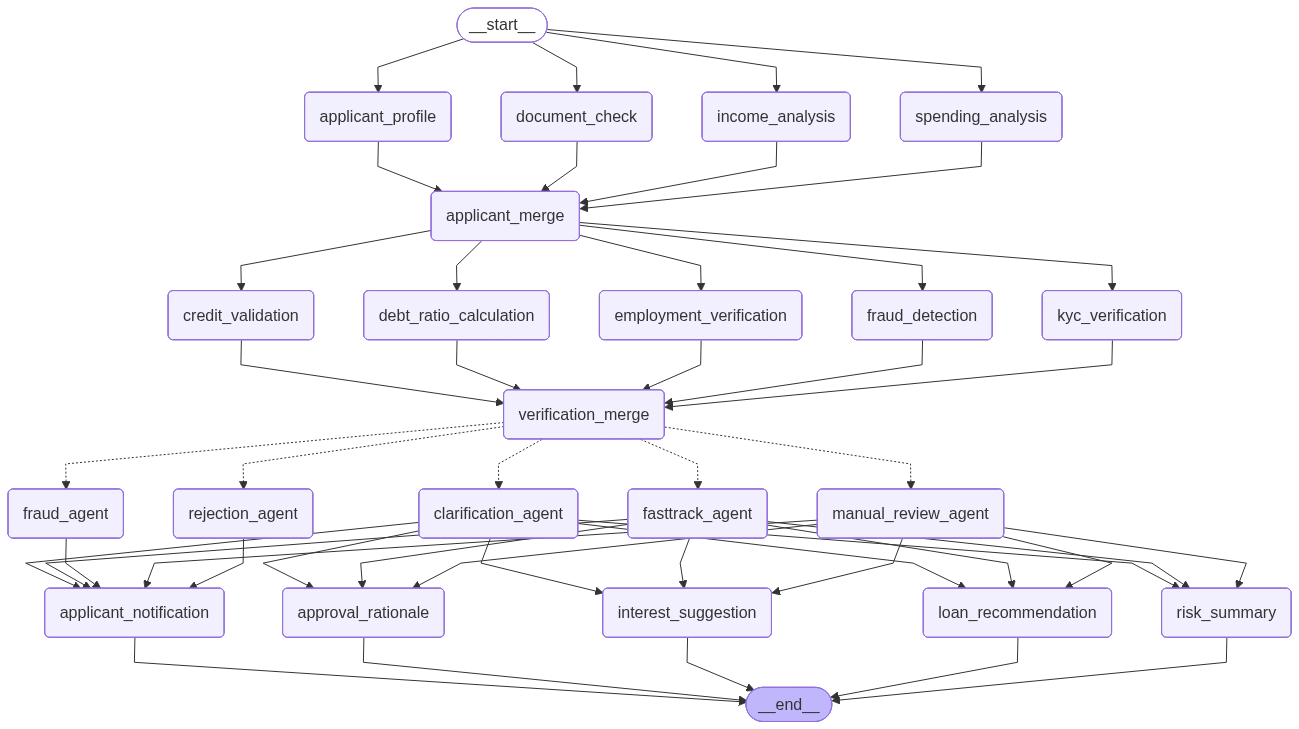

In [99]:
workflow

In [100]:
result = workflow.invoke(
    {
        "applicant_input": """
        Permanent employee with excellent credit.
        Stable salary.
        No missing documents.
        Low debt.
        """
    }
)
print(result)

Applicant Analysis Completed
Verification Layer Completed
Fast-track Approval Agent Activated
{'applicant_input': '\n        Permanent employee with excellent credit.\n        Stable salary.\n        No missing documents.\n        Low debt.\n        ', 'applicant_profile': 'This applicant presents an **exceptionally strong and low-risk profile**.\n\nThey are a permanent employee with a stable salary, possess excellent credit, and maintain low debt. All necessary documentation is complete, making them an **ideal candidate** for a loan.', 'income_stability': 'stable', 'missing_documents': True, 'spending_behavior': 'moderate', 'financial_behavior': 'moderate', 'credit_score': 790, 'fraud_probability': 'low', 'kyc_status': 'verified', 'employment_status': 'verified', 'debt_ratio': 28.0, 'assigned_department': 'Fast-track Approval Team', 'approval_decision': 'Pre-Approved', 'risk_summary': '\n    Credit Score:\n    790\n\n    Fraud Probability:\n    low\n\n    Debt Ratio:\n    28.0\n    ',

In [101]:
result = workflow.invoke(
    {
        "applicant_input": """
        Applicant submitted fake salary documents.
        Permanent employee.
        Good credit history.
        """
    }
)

print(result)

Applicant Analysis Completed
Verification Layer Completed
Fraud Investigation Agent Activated
{'applicant_input': '\n        Applicant submitted fake salary documents.\n        Permanent employee.\n        Good credit history.\n        ', 'applicant_profile': 'This applicant presents a mixed, but ultimately concerning, profile:\n\n**Applicant Profile Summary:**\n\nThe applicant has a positive credit history and stable employment as a permanent employee. However, these strengths are severely undermined by the deliberate submission of fake salary documents, indicating a significant integrity issue, potential fraud, and an inability to verify their actual income and repayment capacity. This makes them a high-risk applicant despite their good credit.', 'income_stability': 'stable', 'missing_documents': False, 'spending_behavior': 'moderate', 'financial_behavior': 'moderate', 'credit_score': 720, 'fraud_probability': 'high', 'kyc_status': 'verified', 'employment_status': 'verified', 'debt_r